# Eddy Flux

In [1]:
from smode_import import *

In [2]:
# load thermosalinograph data

TSG = xr.open_dataset('../S_MODE_IOP2_SRIDE23_tsg_met_bio.nc')
TSG = TSG.drop_duplicates(dim='time_bio')
TSG = TSG.drop_duplicates(dim='time')
flowrate_time_bio = TSG['flow_rate_lab_tsg'].interp(time=TSG['time_bio'], method='linear')
TSG['flowrate_time_bio'] = (TSG.chlorophyll_ACS.dims, flowrate_time_bio.values)
TSG

<xarray.Dataset> Size: 40MB
Dimensions:                              (time_bio: 32509, time: 147912,
                                          instrument: 1)
Coordinates:
  * time_bio                             (time_bio) datetime64[ns] 260kB 2023...
    latitude_bio                         (time_bio) float64 260kB ...
    longitude_bio                        (time_bio) float64 260kB ...
  * time                                 (time) datetime64[ns] 1MB 2023-04-07...
    latitude                             (time) float64 1MB ...
    longitude                            (time) float64 1MB ...
Dimensions without coordinates: instrument
Data variables: (12/47)
    TSG86                                (instrument) float64 8B ...
    TSG73                                (instrument) float64 8B ...
    SST62                                (instrument) float64 8B ...
    FLW19                                (instrument) float64 8B ...
    FLW20                                (instrument) float64 8B ...
    FLW09                                (instrument) float64 8B ...
    ...                                   ...
    beam_attenuation_657nm_ACS           (time_bio) float64 260kB ...
    chlorophyll_flourometer              (time_bio) float64 260kB ...
    particulate_organic_carbon_cstar     (time_bio) float64 260kB ...
    photosynthetically_active_radiation  (time_bio) float64 260kB ...
    CSTAR_QCflag                         (time_bio) float64 260kB ...
    flowrate_time_bio                    (time_bio) float64 260kB 2.844 ... 1...
Attributes: (12/52)
    DOI:                           10.5067/SMODE-RVTSG
    title:                         SMODE Shipboard bio-optical, meteorlogical...
    summary:                       Level-2 processed data from GPS, TSG and F...
    keywords:                      EARTH SCIENCE > OCEANS > OPTICS > ATTENUAT...
    keywords_vocabulary:           NASA Global Change Master Directory (GCMD)...
    conventions:                   CF-1.8, ACDD-1.3
    ...                            ...
    timetime_coverage_end:         2023-05-03T15:05:07Z
    geospatial_vertical_units:     m
    geospatial_vertical_positive:  down
    date_created:                  2023-04-13T00:00:00Z
    time_coverage_duration:        P25D20H10M57S
    comment:                       See readme.txt. Thermosalinograph Data are...

## POC concentration composite

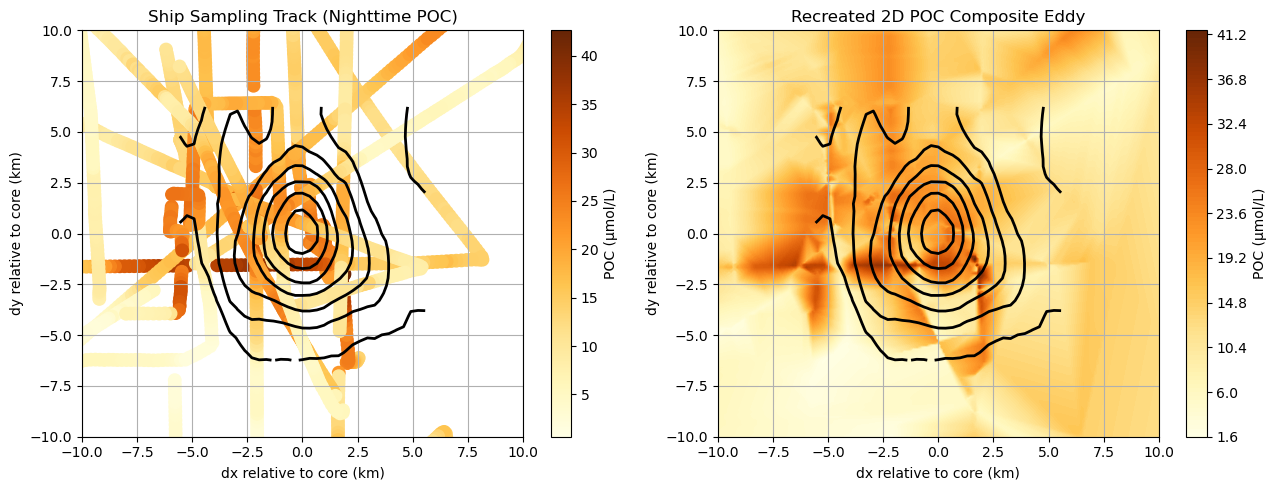

In [3]:
# POC composite

from scipy.interpolate import griddata
ds_interpolated = xr.open_dataset('../eddy_core_position.nc')

# get POC [μmol L-1] during the eddy time window
ACS_eddy_times = TSG['particulate_organic_carbon_acs'].sel(time_bio=slice('2023-04-18', '2023-04-23'))
upper_bound = 50  # Filter out outliers / biofouling spikes

# interpolate eddy core track onto ship sampling time
ds_interpolated_on_ACS = ds_interpolated.interp(time=ACS_eddy_times.time_bio, method='quadratic')

# calculate spatial offsets (dx, dy) in km relative to the eddy core
dlat = ds_interpolated_on_ACS.lat - ACS_eddy_times.latitude_bio
dlon = ds_interpolated_on_ACS.lon - ACS_eddy_times.longitude_bio

dy_km = dlat * 111320 / 1e3
dx_km = dlon * (111320 * np.cos(np.radians(ds_interpolated_on_ACS.lat.values))) / 1e3
dist_from_core = np.sqrt(dx_km**2 + dy_km**2)

# keep night-time values only to remove photochemical quenching
def is_night(timestamp, delta=-7):  # UTC to PST
    return (timestamp.dt.hour < 9 - delta) | (timestamp.dt.hour >= 17 - delta)

idx = (
    (~np.isnan(ACS_eddy_times)) & # remove nans
    (~np.isnan(dy_km)) &
    (~np.isnan(dx_km)) &
    (ACS_eddy_times < upper_bound) & # remove excessive values
    (is_night(ACS_eddy_times.time_bio)) # keep nighttime values
)

dx_km = dx_km[idx].values 
dy_km = dy_km[idx].values
poc_umol_L = ACS_eddy_times.values[idx]  # [μmol / L]

# POC 2D composite

# uniform 2D grid [-10, 10] km relative to eddy core
grid_resolution = 200 # [m]
dist_max = 10
x_line = np.linspace(-dist_max, dist_max, grid_resolution)
y_line = np.linspace(-dist_max, dist_max, grid_resolution)
x_2d, y_2d = np.meshgrid(x_line, y_line)

# interpolate ship track POC values onto the 2D grid
poc_2d = griddata((dx_km, dy_km), poc_umol_L, (x_2d, y_2d), method='linear')

# calculate distance from core for every pixel on the 2D grid [km]
dist_2d = np.sqrt(x_2d**2 + y_2d**2)

# plot
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# overlay vorticity contours
composite_eddy = xr.open_dataset('../composite_eddy_centered.nc')
for axis in ax:
    composite_eddy.vor_eddy.plot.contour(levels=np.linspace(-2,2,16),colors='k',linewidths=2,ax=axis,zorder=101)

# Left: individual points along ship track
p0 = ax[0].scatter(dx_km, dy_km, c=poc_umol_L, s=80, cmap='YlOrBr')
ax[0].set_title("Ship Sampling Track (Nighttime POC)")
ax[0].set_xlabel("dx relative to core (km)")
ax[0].set_ylabel("dy relative to core (km)")
ax[0].set_xlim(-dist_max, dist_max)
ax[0].set_ylim(-dist_max, dist_max)
ax[0].grid(True)
plt.colorbar(p0, ax=ax[0], label="POC (μmol/L)")

# Right: interpolated 2D POC composite
p1 = ax[1].contourf(x_2d, y_2d, poc_2d, levels=100, cmap='YlOrBr')
ax[1].set_title("Recreated 2D POC Composite Eddy")
ax[1].set_xlabel("dx relative to core (km)")
ax[1].set_ylabel("dy relative to core (km)")
ax[1].set_xlim(-dist_max, dist_max)
ax[1].set_ylim(-dist_max, dist_max)
ax[1].grid(True)
plt.colorbar(p1, ax=ax[1], label="POC (μmol/L)")

plt.tight_layout()
plt.show()

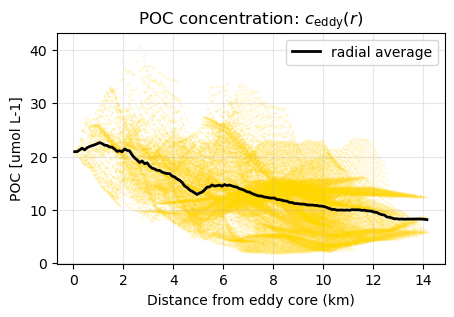

In [4]:
# POC as a function from dist_from_core (from 0 to 10 km)

dist_radial = np.sqrt(x_2d**2 + y_2d**2)

bin_width = 0.1 # [km]
r_bins = np.arange(0, np.max(dist_radial) + bin_width, bin_width)
r_centers = (r_bins[:-1] + r_bins[1:]) / 2.0 # for plotting

# initialize
poc_radial_mean = np.zeros(len(r_centers))
poc_radial_std = np.zeros(len(r_centers))

for i in range(len(r_centers)):
    bin_mask = (dist_2d >= r_bins[i]) & (dist_2d < r_bins[i+1]) & (~np.isnan(poc_2d))
    
    if np.any(bin_mask):
        poc_radial_mean[i] = np.mean(poc_2d[bin_mask])
        poc_radial_std[i] = np.std(poc_2d[bin_mask])
    else:
        poc_radial_mean[i] = np.nan
        poc_radial_std[i] = np.nan

# plot
plt.figure(figsize=(5,3))
plt.scatter(dist_radial, poc_2d.flatten(), s=1, c='gold', alpha=0.1)
plt.plot(r_centers, poc_radial_mean, c='k', lw=2, label='radial average')

plt.legend()
plt.grid(alpha=0.3)
plt.xlabel('Distance from eddy core (km)')
plt.ylabel('POC [umol L-1]')
plt.title(r'POC concentration: $c_{\text{eddy}}(r)$')
plt.show();

## Submesoscale Eddy POC Inventory

To total POC inventory of our submesoscale eddy is:
$$
M_{\text{eddy}} = MLD \times 2\pi \int_{0}^{R_{\text{eddy}}} c_{\text{eddy}}(r)~rdr
$$

where $c_{\text{eddy}}$ is the measured POC concentration averaged from TSG, $R_{\text{eddy}}$ is the eddy's radius ($5~km$), MLD is the mixed-layer depth ($25~m$).

Note that any variable with subscript $_{\text{eddy}}$ refers to our own submesoscale eddy.

In [6]:
from scipy.integrate import trapezoid

# parameters
MW_C = 12.011   # Molecular weight of carbon (mg/mmol or g/mol)
MLD = 25      # Mixed-layer depth (m)
R_eddy = 5000 # Eddy radius (m)

# keep data within 5 km
r_m = r_centers * 1000.0 # km to m
mask = ~np.isnan(poc_radial_mean) & ~np.isnan(poc_radial_std) & (r_m <= R_eddy)

r_valid = r_m[mask]
poc_mean_valid = poc_radial_mean[mask] # mmol m-3
poc_std_valid = poc_radial_std[mask]   # mmol m-3

# integral
poc_integration_mean = trapezoid(poc_mean_valid * r_valid, x=r_valid) # mmol m-1
M_eddy_mmol = MLD * 2*np.pi * poc_integration_mean # [mmol C]

# conversion mol to grams
M_eddy_g = M_eddy_mmol * MW_C / 1000.0   # [g C]
M_eddy_Gg = M_eddy_mmol * MW_C/ 1e12 # [Gg C]

# std propagation (trapezoidal rule)
weights = np.gradient(r_valid)
std_integration = np.sqrt(np.sum((weights * r_valid * poc_std_valid)**2))

M_eddy_std_mmol = MLD * 2*np.pi * std_integration # [mmol C]
M_eddy_std_Gg = (M_eddy_std_mmol * MW_C) / 1e12       # [Gg C]

# volumetric concentration (we divide by eddy volume)
V_eddy = np.pi * (R_eddy**2) * MLD # m^3
C_bar_eddy = M_eddy_mmol / V_eddy  # [mmol m^-3]
C_bar_eddy_std = M_eddy_std_mmol / V_eddy  # [mmol m^-3]

#print(f"Total POC Inventory: {C_eddy_mmol:.2e} +/- {C_eddy_std_mmol:.2e} mmol C")
print(f"Eddy POC Inventory: {M_eddy_Gg:.4f} ± {M_eddy_std_Gg:.4f} Gg C")
print(f"Eddy POC Concentration: {C_bar_eddy:.2f} ± {C_bar_eddy_std:.2f} mmol m-3")

Eddy POC Inventory: 0.4051 ± 0.0192 Gg C
Eddy POC Concentration: 17.18 ± 0.81 mmol m-3


## POC Eddy Export Flux

The lateral eddy export flux of POC is given by:
$$
F' = u_{\text{eddy}} \times \bar{C}' \times \hat{f}
$$

* $u_{\text{eddy}}$ is the zonal velocity inferred from our submesoscale eddy position from Dopplerscatt observations
* $C'$ is the POC concentration anomaly ($\text{mmol m}^{-3}$) relative to the ambient background using satellite imagery of surface POC
* $\hat{f}$ is spatial fraction ($0 \le \hat{f} \le 1$) of eddy occupation along the cloud-free 124$\degree$W line, from 33 to 39$\degree$N


In [7]:
# Zonal velocity
# we assume our eddy's u is average, not in paper's limitations
u_eddy = 0.05 # m s-1

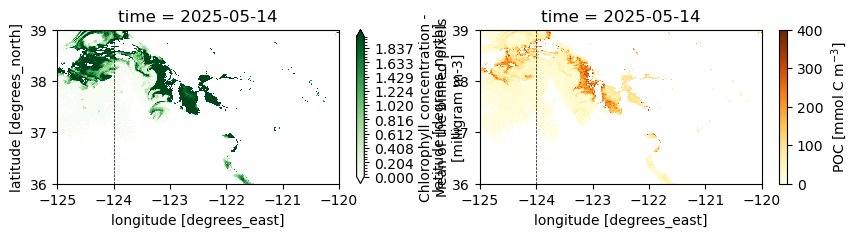

In [43]:
from glob import glob
MW_C = 12.011

OLCI_files = glob('../olci_300m_downloads/*')

for file in OLCI_files:
    chl_300m = xr.open_dataset(file)['CHL']

    chl_300m_log = np.log(chl_300m)

    # Loisel et al. / Stramski et al. conversion algorithm
    poc_mg_m3 = 308.28 * (chl_300m ** 0.56) # to POC mass concentration [mg/m3]
    poc_mmol_m3 = poc_mg_m3 / MW_C # to molar concentration [mmol C / m3]

    time_str = str(chl_300m.time.values)[2:12]

    fig, ax = plt.subplots(1,2,figsize=(10,2))

    chl_300m_log.plot(levels=np.linspace(0,2,50),extend='both', ax=ax[0], cmap='Greens') # log chl
    #poc_mg_m3.plot(ax=ax[1], cmap='Oranges') # mass concentration
    poc_mmol_m3.plot(ax=ax[1], cmap='YlOrBr',vmin=0,vmax=400,cbar_kwargs={'label': r'POC [mmol C m$^{-3}$]'}) # mol concentration
    for axis in ax:
        axis.axvline(-124,color='k',linestyle='--',lw=0.5)
    
    plt.show();
    
    break

#C_bar_prime = 

'2023-08-26'

In [ ]:
F_prime_per_sec = u_eddy * C_bar_prime * f_hat # [mmol C m-2 s-1]

F_prime_per_day = F_prime_per_sec * 86400 # [mmol C m-2 d-1]

In [ ]:
# integrated lateral from
F_prime_per_day * MLD

$$
L_{124\degree W} \times MLD
$$